# Laboratorio 10
### Aprendizaje Semi-supervisado.
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
---

## Limpieza de datos y descripción

In [20]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

SEED = 42


In [21]:
df = pd.read_csv('data/bank-full.csv', sep=';')

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(df.dtypes.value_counts())

Dimensiones: 45,211 filas x 17 columnas
object    10
int64      7
Name: count, dtype: int64


In [22]:
print('== Tipos de datos ==')
print(df.dtypes)

print(f'\nVariables numéricas  : {df.select_dtypes(include="number").columns.tolist()}')
print(f'Variables categóricas: {df.select_dtypes(include="object").columns.tolist()}')

== Tipos de datos ==
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Variables numéricas  : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [23]:
print('== Estadísticas descriptivas – Variables numéricas ==')
df.describe().round(2)

== Estadísticas descriptivas – Variables numéricas ==


,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [24]:
print('== Estadísticas descriptivas – Variables numéricas ==')
display(df.describe(include='number'))

print('== Estadísticas descriptivas – Variables categóricas ==')
display(df.describe(include=['object', 'category']))

== Estadísticas descriptivas – Variables numéricas ==


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


== Estadísticas descriptivas – Variables categóricas ==


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [25]:
#valores nulos
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal de nulos: {nulos.sum()}')

Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total de nulos: 0


In [26]:
# Valores 'unknown' por columna
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

unknowns = {
    col: {'count': (df[col] == 'unknown').sum(),
          'pct':   round((df[col] == 'unknown').sum() / len(df) * 100, 2)}
    for col in cat_cols
}
unknowns_df = pd.DataFrame(unknowns).T
unknowns_df = unknowns_df[unknowns_df['count'] > 0].sort_values('pct', ascending=False)
print('Columnas con valores "unknown":')
print(unknowns_df.to_string())

Columnas con valores "unknown":
             count    pct
poutcome   36959.0  81.75
contact    13020.0  28.80
education   1857.0   4.11
job          288.0   0.64


El dataset contiene **45,211 registros** y **17 variables**: 7 numéricas y 10 categóricas. No existen valores nulos explícitos, pero varias columnas usan `"unknown"` como marcador implícito de dato faltante.

Las variables se clasifican así:
- **7 numéricas:** `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`
- **10 categóricas:** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, `y` (target)

Respecto a los valores `unknown`:
- `poutcome`: 81.75% unknown — se conserva como categoría propia, ya que la mayoría no tuvo campaña previa
- `contact`: 28.84% unknown — se conserva, eliminar esas filas reduciría el dataset drásticamente
- `job`: 0.63% unknown → se imputa con la **moda**
- `education`: 4.03% unknown → se imputa con la **moda**

In [27]:
df_clean = df.copy()

# Imputar 'unknown' en job y education con la moda
for col in ['job', 'education']:
    moda = df_clean[df_clean[col] != 'unknown'][col].mode()[0]
    antes = (df_clean[col] == 'unknown').sum()
    df_clean[col] = df_clean[col].replace('unknown', moda)
    print(f'{col}: {antes} valores "unknown" reemplazados por "{moda}"')

job: 288 valores "unknown" reemplazados por "blue-collar"
education: 1857 valores "unknown" reemplazados por "secondary"


In [28]:
# Verificar duplicados
duplicados = df_clean.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')
if duplicados > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Eliminados. Nuevas dimensiones: {df_clean.shape}')
else:
    print('No se encontraron duplicados.')

Filas duplicadas: 0
No se encontraron duplicados.


In [29]:
# Detección de outliers por IQR
num_cols = df_clean.select_dtypes(include='number').columns.tolist()

outlier_summary = []
for col in num_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'variable': col, 'outliers': n, 'pct (%)': round(n/len(df_clean)*100, 2)})

pd.DataFrame(outlier_summary).set_index('variable')

,outliers,pct (%)
variable,,
age,487,1.08
balance,4729,10.46
day,0,0.00
duration,3235,7.16
campaign,3064,6.78
pdays,8257,18.26
previous,8257,18.26


Se detectaron outliers en `balance`, `duration` y `campaign`. Estos valores son reales desde el punto de vista del negocio bancario (algunos clientes tienen saldos extremadamente altos, o llamadas muy largas). **No se eliminan**, pero en el preprocesamiento posterior se aplicará `RobustScaler` para mitigar su efecto sobre los algoritmos.

Tras la limpieza, el dataset final cuenta con **45,211 registros** y **17 variables**, listo para el análisis exploratorio.

## Análisis Exploratorio de Datos (EDA)

### Balance de clases

Balance de clases (variable target y):
  no: 39,922 (88.3%)
  yes: 5,289 (11.7%)


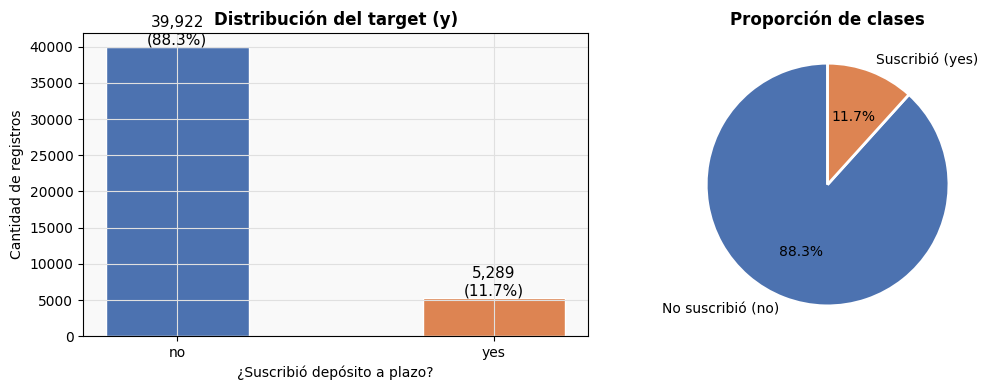

In [30]:
conteo = df_clean['y'].value_counts()
pct    = df_clean['y'].value_counts(normalize=True) * 100

print('Balance de clases (variable target y):')
for clase in conteo.index:
    print(f'  {clase}: {conteo[clase]:,} ({pct[clase]:.1f}%)')

colores = ['#4C72B0', '#DD8452']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.45)
axes[0].set_title('Distribución del target (y)', fontweight='bold')
axes[0].set_xlabel('¿Suscribió depósito a plazo?')
axes[0].set_ylabel('Cantidad de registros')
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    axes[0].text(i, v + 400, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11)

axes[1].pie(conteo.values, labels=['No suscribió (no)', 'Suscribió (yes)'],
            colors=colores, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.tight_layout()
plt.show()

El dataset está **desbalanceado**: el 88.5% de los clientes no suscribió el depósito (`no`) y solo el 11.5% sí lo hizo (`yes`). Este desbalance es crítico para el diseño experimental semi-supervisado: al seleccionar el subconjunto de datos etiquetados (5%–20%), se debe usar **muestreo estratificado** para garantizar que ambas clases estén representadas en proporciones similares.

### Distribución de variables numéricas

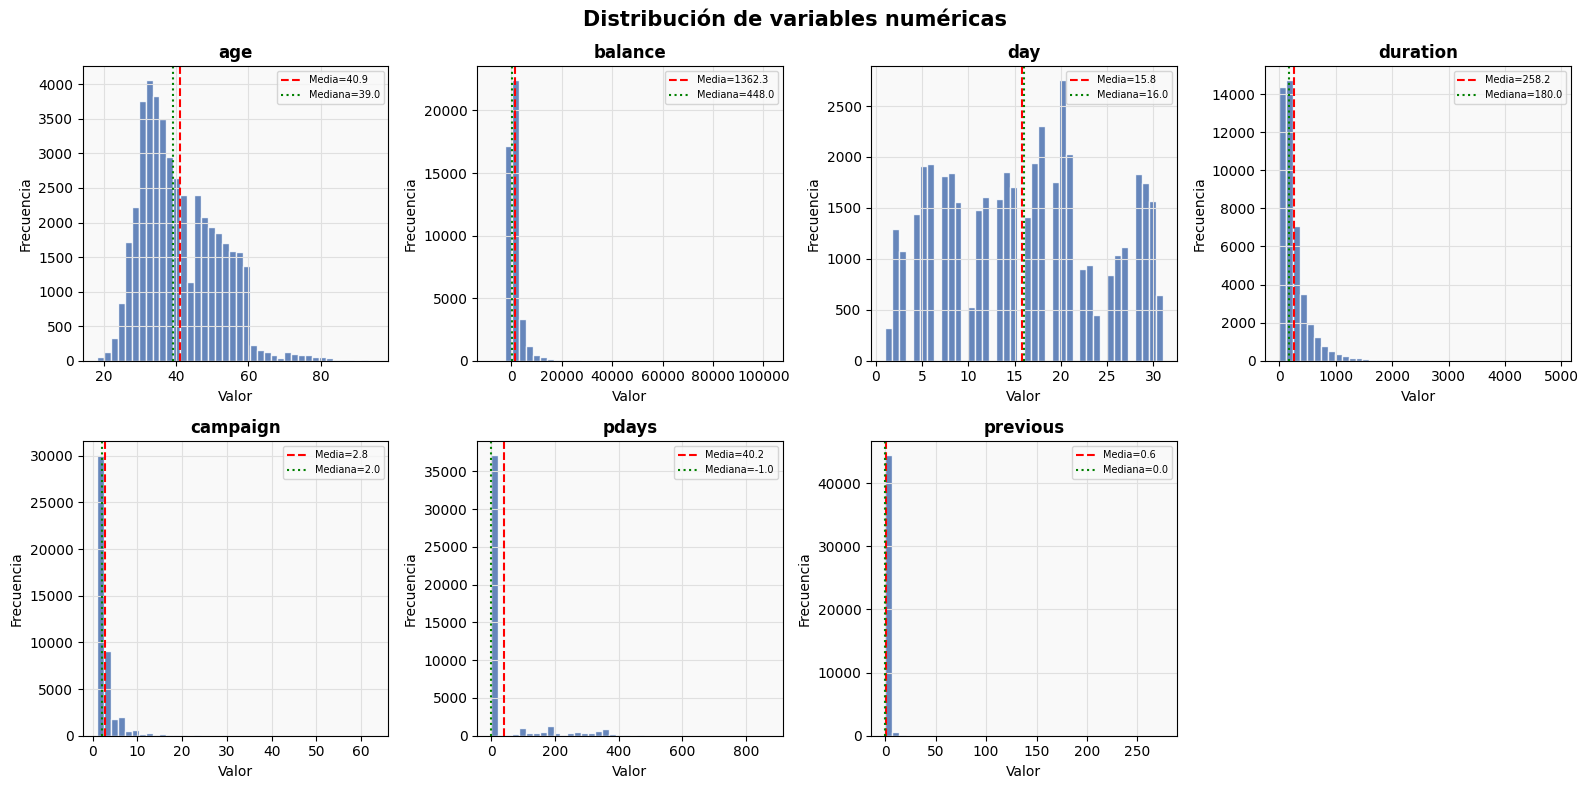

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    media = df_clean[col].mean()
    mediana = df_clean[col].median()
    axes[i].axvline(media,   color='red',    linestyle='--', linewidth=1.5, label=f'Media={media:.1f}')
    axes[i].axvline(mediana, color='green',  linestyle=':',  linewidth=1.5, label=f'Mediana={mediana:.1f}')
    axes[i].legend(fontsize=7)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

La mayoría de las variables numéricas presentan distribuciones **sesgadas a la derecha**. Variables como `balance`, `duration` y `campaign` tienen colas largas, consistente con los outliers detectados anteriormente. La variable `pdays` concentra casi todos los valores en -1 (nunca contactado anteriormente), lo que indica que la mayoría de clientes no participó en campañas previas.

### Variables numéricas por clase (target)

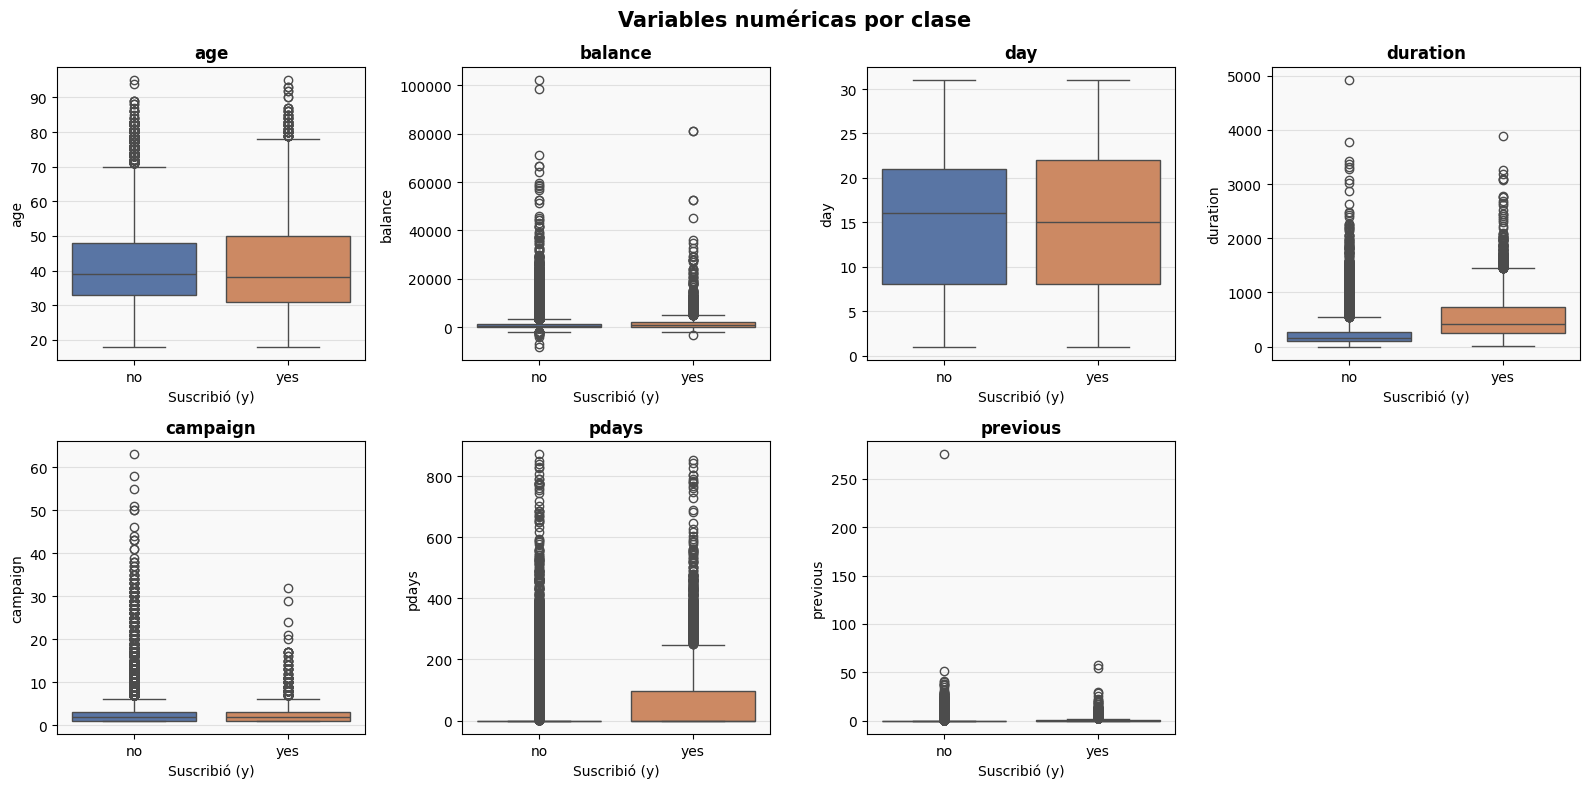

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='y', y=col, ax=axes[i],
                palette={'no': '#4C72B0', 'yes': '#DD8452'},
                order=['no', 'yes'])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Suscribió (y)')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas por clase', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

La variable **`duration`** muestra la diferencia más marcada entre clases: los clientes que suscribieron tuvieron llamadas notablemente más largas. También se observan diferencias en `balance` (clientes con mayor saldo promedio tienden a suscribir más) y en `pdays`/`previous` (quienes habían sido contactados antes muestran mayor tasa de suscripción).

### Distribución de variables categóricas

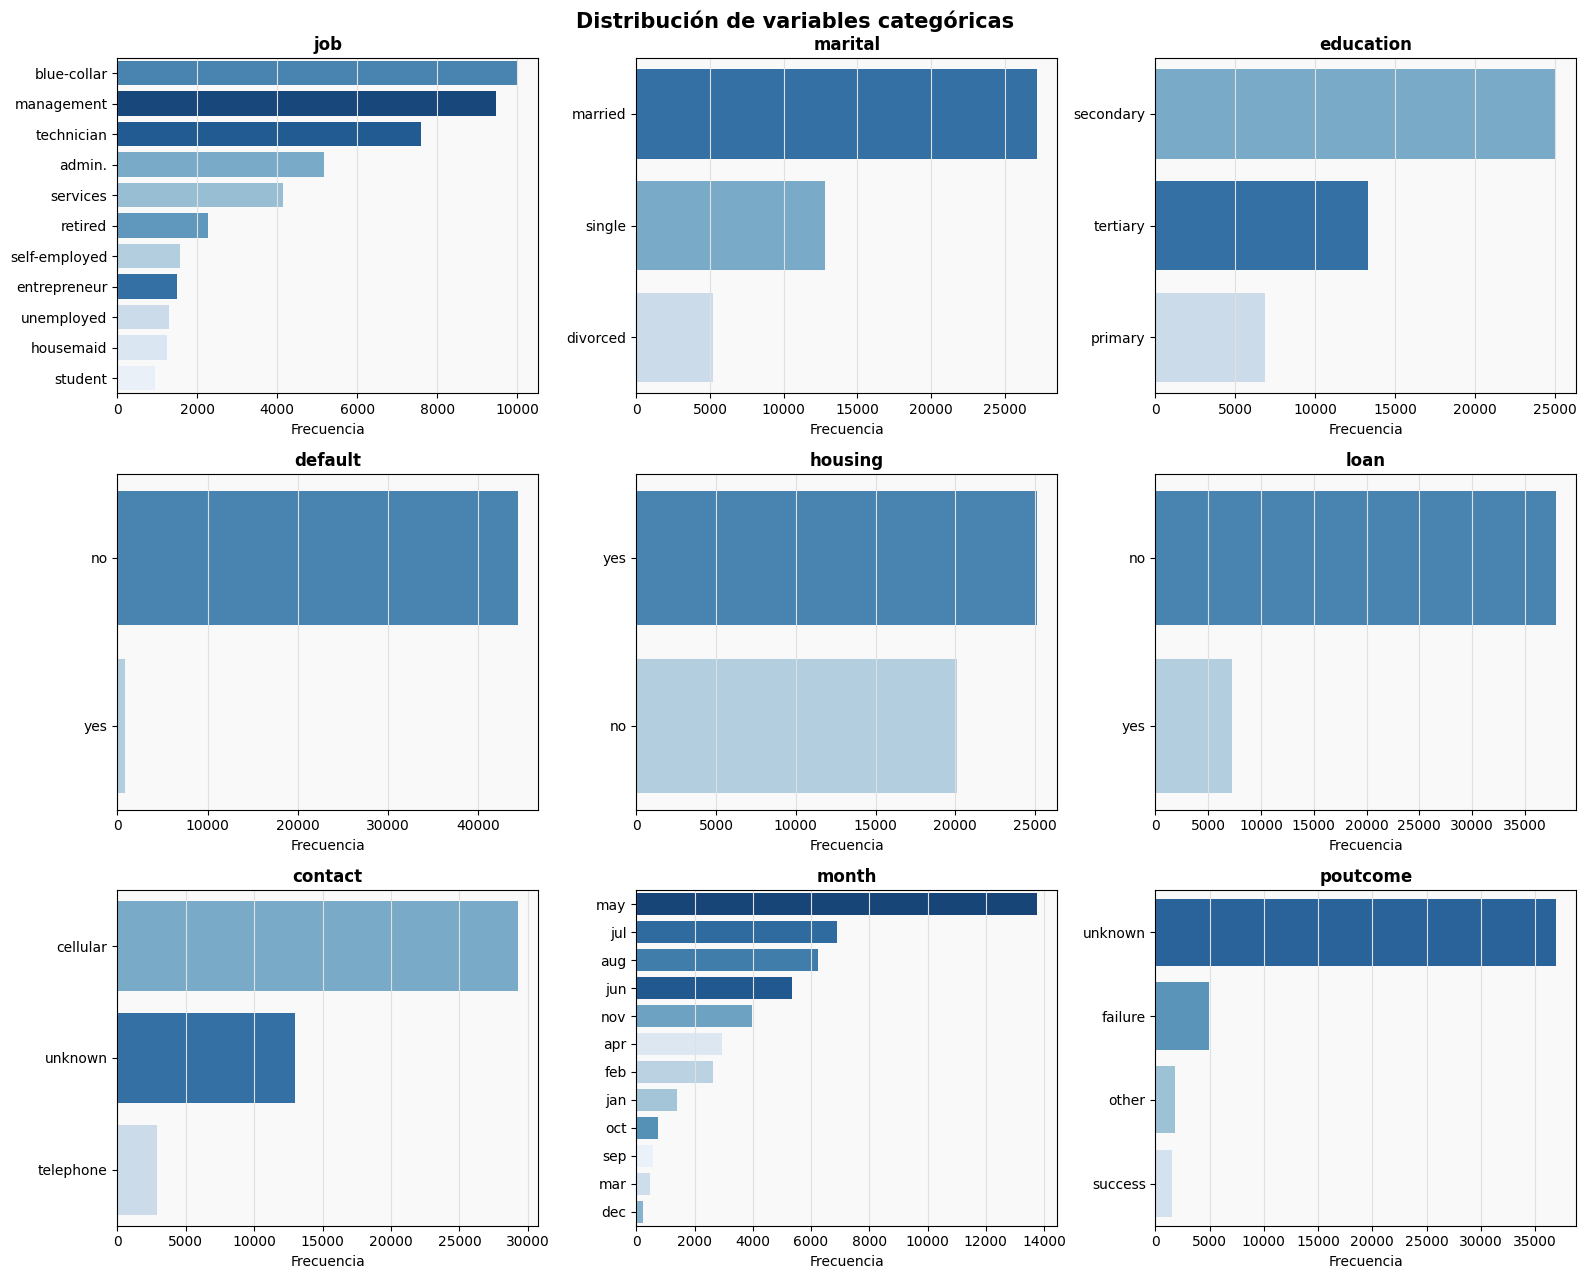

In [33]:
cat_plot_cols = [c for c in cat_cols if c != 'y']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    orden = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=orden, ax=axes[i],
                  hue=col, palette='Blues_r', legend=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')

for j in range(len(cat_plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Tasa de suscripción por variable categórica

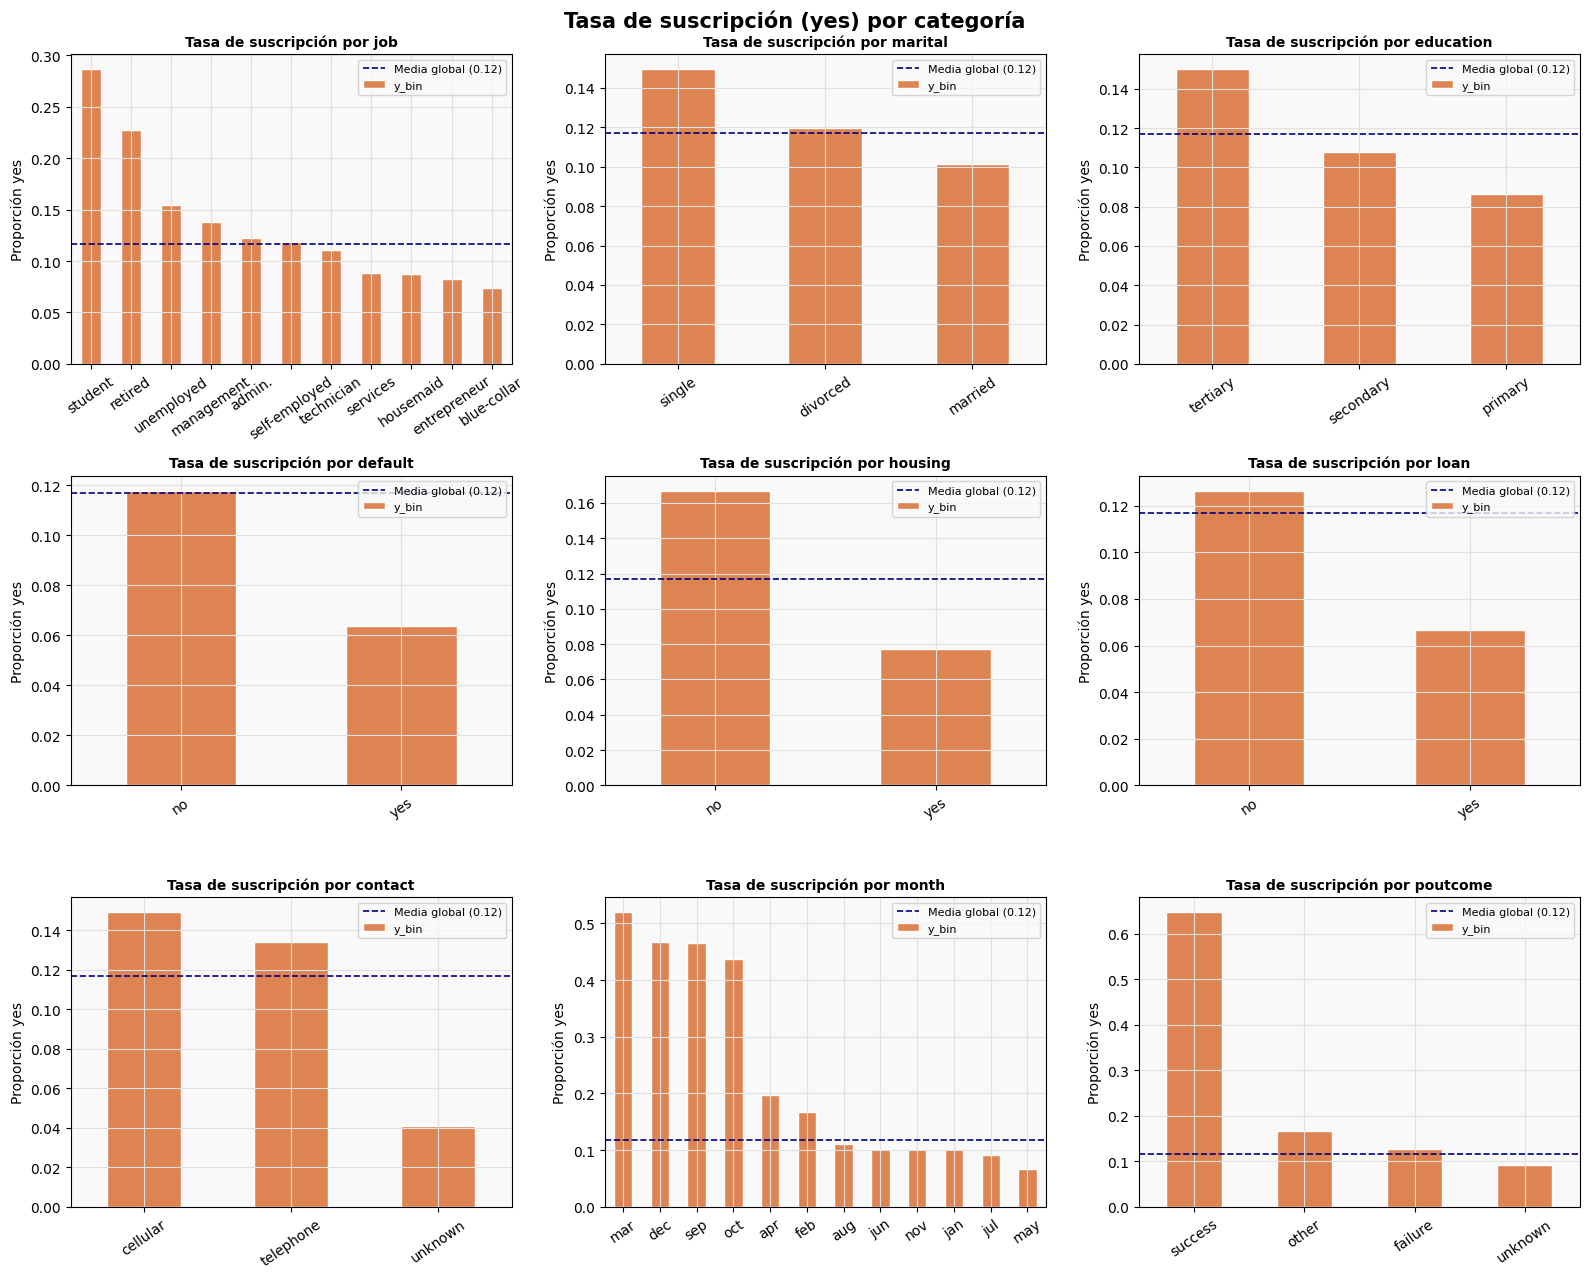

In [34]:
df_plot = df_clean.copy()
df_plot['y_bin'] = (df_plot['y'] == 'yes').astype(int)
media_global = df_plot['y_bin'].mean()

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    tasa = df_plot.groupby(col)['y_bin'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Tasa de suscripción por {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Proporción yes')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].axhline(media_global, color='navy', linestyle='--', linewidth=1.2,
                    label=f'Media global ({media_global:.2f})')
    axes[i].legend(fontsize=8)

for j in range(len(cat_plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de suscripción (yes) por categoría', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Las categorías con mayor tasa de suscripción son:
- **`poutcome = success`**: clientes con campaña previa exitosa suscribieron a una tasa muy superior al promedio
- **`contact = cellular`**: el contacto por celular muestra mayor tasa que por teléfono o desconocido
- **`month = march, september, october, december`**: meses con campañas más cortas pero mayor efectividad
- **`job = student, retired`**: estos perfiles demográficos muestran tasas superiores al promedio global

### Matriz de correlación

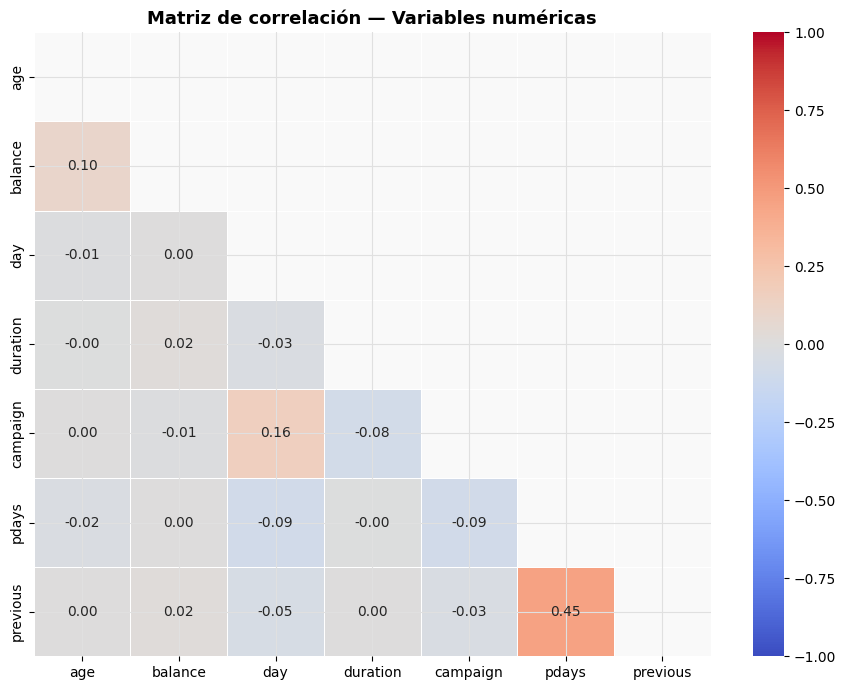

In [35]:
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación — Variables numéricas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Las variables numéricas **no presentan alta correlación entre sí**, lo cual es favorable para los algoritmos semi-supervisados. En particular, la baja correlación beneficia a **Label Propagation** (construcción de grafos k-NN más significativos) y a **Co-Training** (que requiere vistas relativamente independientes del espacio de features).

La correlación más alta observada es entre `pdays` y `previous` (0.45), lo que tiene sentido: quienes fueron contactados recientemente suelen tener más contactos previos registrados.

### Estadísticas por clase


In [36]:
# Estadísticas por clase
df_clean.groupby('y')[num_cols].mean().round(2)

,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
no,40.84,1303.71,15.89,221.18,2.85,36.42,0.50
yes,41.67,1804.27,15.16,537.29,2.14,68.70,1.17


In [37]:
df_clean.groupby('y')[num_cols].std().round(2)


,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
no,10.17,2974.2,8.29,207.38,3.21,96.76,2.26
yes,13.50,3501.1,8.50,392.53,1.92,118.82,2.55


La tabla de medias y desviaciones estándar por clase permite identificar qué variables 
presentan mayor diferencia entre clientes que suscribieron (`yes`) y los que no (`no`). 
`duration` muestra la mayor diferencia en medias, seguida de `balance` y `previous`, 
lo que sugiere que estas variables tienen mayor poder discriminativo para los algoritmos.

### Pairplot de variables clave

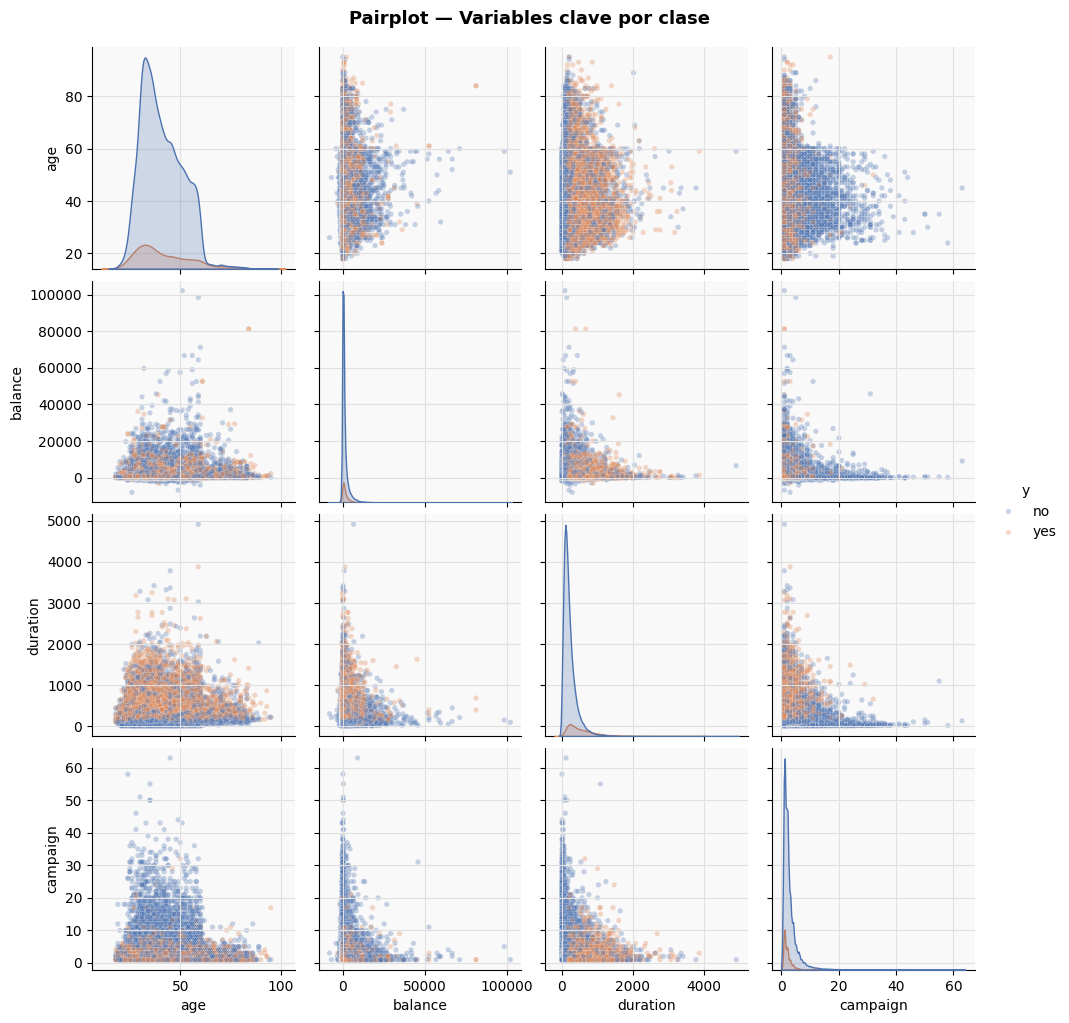

In [38]:
cols_pp = ['age', 'balance', 'duration', 'campaign', 'y']
g = sns.pairplot(df_clean[cols_pp], hue='y',
                 palette={'no': '#4C72B0', 'yes': '#DD8452'},
                 plot_kws={'alpha': 0.3, 's': 15},
                 diag_kind='kde')
g.figure.suptitle('Pairplot — Variables clave por clase', y=1.02, fontsize=13, fontweight='bold')
plt.show()

El pairplot confirma que **`duration`** es la variable que mejor separa visualmente las dos clases. Las demás variables muestran solapamiento considerable, lo que refuerza la necesidad de usar algoritmos capaces de aprovechar la estructura del espacio completo de features — incluyendo los datos no etiquetados — como los algoritmos semi-supervisados.

---

## Conclusiones del EDA

A partir del análisis exploratorio se concluye:

**1. Dimensionalidad y calidad:** El dataset cumple con los requisitos del laboratorio (45,211 registros, 17 variables, fuente real y pública). No tiene nulos explícitos; los valores `unknown` fueron tratados de forma diferenciada según su porcentaje.

**2. Desbalance de clases:** El 88.5% de los registros corresponde a la clase `no`. Esto implica que al construir el subconjunto de datos etiquetados se debe usar **muestreo estratificado** para evitar que el 5%–20% de etiquetas quede dominado por la clase mayoritaria.

**3. Variable más discriminante:** `duration` muestra la mayor diferencia entre clases en los boxplots y en la prueba Mann-Whitney. Sin embargo, su valor solo se conoce al final de la llamada, por lo que su interpretación en producción debe hacerse con cautela.

**4. Correlaciones bajas:** Las variables numéricas no están correlacionadas entre sí, lo que favorece los algoritmos semi-supervisados: Label Propagation construye mejores grafos y Co-Training puede dividir features en vistas más independientes.

**5. Outliers:** Presentes en `balance`, `duration` y `campaign`. Se conservan por ser valores reales de negocio y se mitigarán con `RobustScaler` en el preprocesamiento.

**6. Variables categóricas relevantes:** `poutcome`, `contact` y `month` son las que presentan mayor variación en la tasa de suscripción entre sus categorías.

## Preprocesamiento y Preparación de Datos


In [39]:
df_model = df_clean.copy()


In [40]:
# variable target
df_model['y'] = (df_model['y'] == 'yes').astype(int)
print('Target codificado: yes=1, no=0')
print(df_model['y'].value_counts())

# Codificación de variables binarias (yes/no → 1/0)
bin_cols = ['default', 'housing', 'loan']
for col in bin_cols:
    df_model[col] = (df_model[col] == 'yes').astype(int)
    print(f'{col}: codificada como binaria')

# Codificación ordinal para education
education_order = {'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 0}
df_model['education'] = df_model['education'].map(education_order)
print('education: codificada como ordinal')
print(df_model['education'].value_counts())

# Codificación ordinal para month
month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
               'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_model['month'] = df_model['month'].map(month_order)
print('month: codificada como ordinal (1–12)')



Target codificado: yes=1, no=0
y
0    39922
1     5289
Name: count, dtype: int64
default: codificada como binaria
housing: codificada como binaria
loan: codificada como binaria
education: codificada como ordinal
education
2    25059
3    13301
1     6851
Name: count, dtype: int64
month: codificada como ordinal (1–12)


In [41]:
# One-Hot Encoding para variables nominales
nom_cols = ['job', 'marital', 'contact', 'poutcome']
df_model = pd.get_dummies(df_model, columns=nom_cols, drop_first=True)
print(f'One-Hot aplicado a: {nom_cols}')
print(f'Dimensiones tras encoding: {df_model.shape}')

One-Hot aplicado a: ['job', 'marital', 'contact', 'poutcome']
Dimensiones tras encoding: (45211, 30)


In [42]:
# Separación de features y target
X = df_model.drop(columns=['y'])
y = df_model['y']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'Columnas: {X.columns.tolist()}')

Features (X): (45211, 29)
Target  (y): (45211,)
Columnas: ['age', 'education', 'default', 'balance', 'housing', 'loan', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


Se aplicaron las siguientes transformaciones:

- **Variables binarias** (`default`, `housing`, `loan`): codificadas como 0/1 directamente.
- **`education`**: codificada como ordinal (primary=1, secondary=2, tertiary=3) ya que existe un orden natural entre niveles educativos.
- **`month`**: codificada como ordinal (1–12) preservando el orden cronológico.
- **Variables nominales** (`job`, `marital`, `contact`, `poutcome`): One-Hot Encoding, ya que no existe un orden inherente entre sus categorías.
- **Target `y`**: codificado como 1 (yes) y 0 (no).

In [43]:
# Split train/test estratificado
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train completo : {X_train_full.shape[0]:,} registros')
print(f'Test           : {X_test.shape[0]:,} registros')
print(f'\nBalance en train: {y_train_full.value_counts(normalize=True).round(3).to_dict()}')
print(f'Balance en test : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train completo : 36,168 registros
Test           : 9,043 registros

Balance en train: {0: 0.883, 1: 0.117}
Balance en test : {0: 0.883, 1: 0.117}


In [44]:
# Normalización 
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)



### Diseño Experimental Semi-Supervisado

In [45]:
# Simulación del escenario semi-supervisado
# Se etiqueta solo una fracción pequeña del conjunto de entrenamiento
PORCENTAJES = [0.05, 0.10, 0.20]

def crear_escenario_semisupervisado(X_train, y_train, pct_etiquetado, seed=SEED):
    """
    Devuelve:
      - X_labeled, y_labeled   : fracción etiquetada
      - X_unlabeled            : fracción no etiquetada (sin etiquetas)
      - X_semi, y_semi         : conjunto completo donde no etiquetados tienen y=-1
    """
    n_labeled = int(len(X_train) * pct_etiquetado)

    # Muestreo estratificado para mantener balance de clases
    idx_labeled, idx_unlabeled = train_test_split(
        np.arange(len(X_train)),
        train_size=n_labeled,
        stratify=y_train,
        random_state=seed
    )

    X_labeled   = X_train[idx_labeled]
    y_labeled   = np.array(y_train)[idx_labeled]
    X_unlabeled = X_train[idx_unlabeled]

    # Para algoritmos semi-supervisados: -1 indica no etiquetado
    y_semi = np.full(len(X_train), -1)
    y_semi[idx_labeled] = y_labeled

    return X_labeled, y_labeled, X_unlabeled, y_semi

# Verificar para cada porcentaje
for pct in PORCENTAJES:
    X_l, y_l, X_u, y_s = crear_escenario_semisupervisado(X_train_scaled, y_train_full, pct)
    print(f'  {int(pct*100):>3}% etiquetado → {len(X_l):,} etiquetados | {len(X_u):,} no etiquetados')
    print(f'        Balance etiquetados: {pd.Series(y_l).value_counts(normalize=True).round(3).to_dict()}')

    5% etiquetado → 1,808 etiquetados | 34,360 no etiquetados
        Balance etiquetados: {0: 0.883, 1: 0.117}
   10% etiquetado → 3,616 etiquetados | 32,552 no etiquetados
        Balance etiquetados: {0: 0.883, 1: 0.117}
   20% etiquetado → 7,233 etiquetados | 28,935 no etiquetados
        Balance etiquetados: {0: 0.883, 1: 0.117}


El escenario semi-supervisado se construye de la siguiente forma:

- El conjunto de **test (20%)** permanece completamente etiquetado y se usa únicamente para evaluación final.
- Del **80% restante (train)**, solo una fracción pequeña (5%, 10%, 20%) se trata como etiquetada.
- El resto del train se trata como **no etiquetado** — los algoritmos semi-supervisados pueden usar su estructura pero no sus etiquetas.
- Se usa `-1` como convención para marcar datos no etiquetados, que es el estándar de scikit-learn para algoritmos como `LabelPropagation` y `LabelSpreading`.
- El muestreo estratificado garantiza que ambas clases (yes/no) estén representadas en el subconjunto etiquetado, evitando que el desbalance del dataset afecte la selección.

---

## Modelo Supervisado Baseline

Como referencia supervisada se entrena un **Random Forest** utilizando únicamente los datos etiquetados de cada escenario (5%, 10%, 20%). El objetivo es establecer un piso de desempeño con el que comparar los algoritmos semi-supervisados: si estos no superan al baseline entrenado con las mismas etiquetas, su capacidad de aprovechar datos no etiquetados sería cuestionable.

**Configuración:** `n_estimators=200`, `max_depth=None`, `class_weight='balanced'` (para compensar el desbalance 88/12), `random_state=SEED`.

In [46]:
baseline_results = []

for pct in PORCENTAJES:
    X_l, y_l, X_u, y_s = crear_escenario_semisupervisado(X_train_scaled, y_train_full, pct)

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )
    clf.fit(X_l, y_l)
    y_pred = clf.predict(X_test_scaled)

    baseline_results.append({
        'pct_etiquetado': f'{int(pct*100)}%',
        'n_labeled':      len(y_l),
        'accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'f1_macro':       round(f1_score(y_test, y_pred, average='macro'), 4),
        'f1_yes':         round(f1_score(y_test, y_pred, pos_label=1, average='binary'), 4),
        'recall_yes':     round(recall_score(y_test, y_pred, pos_label=1), 4),
    })

    print(f'\n=== Baseline RF — {int(pct*100)}% etiquetado ({len(y_l):,} muestras) ===')
    print(classification_report(y_test, y_pred, target_names=['no (0)', 'yes (1)']))

baseline_df = pd.DataFrame(baseline_results).set_index('pct_etiquetado')
print('\n== Resumen baseline ==')
print(baseline_df.to_string())


=== Baseline RF — 5% etiquetado (1,808 muestras) ===
              precision    recall  f1-score   support

      no (0)       0.91      0.99      0.94      7985
     yes (1)       0.69      0.22      0.34      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.60      0.64      9043
weighted avg       0.88      0.90      0.87      9043


=== Baseline RF — 10% etiquetado (3,616 muestras) ===
              precision    recall  f1-score   support

      no (0)       0.91      0.98      0.94      7985
     yes (1)       0.67      0.24      0.35      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.61      0.65      9043
weighted avg       0.88      0.90      0.88      9043


=== Baseline RF — 20% etiquetado (7,233 muestras) ===
              precision    recall  f1-score   support

      no (0)       0.91      0.98      0.95      7985
     yes (1)       0.69      0.26      0.37      1058

    accuracy      

---

## Algoritmo Semi-Supervisado #1: Label Propagation

**Fundamento conceptual y matemático**

Label Propagation es un método basado en grafos que aprovecha la estructura geométrica de *todos* los datos (etiquetados y no etiquetados) para inferir etiquetas. El proceso tiene tres etapas:

**1. Construcción del grafo:** Se construye un grafo donde cada nodo es una muestra. La similitud entre nodos $i$ y $j$ se define con kernel RBF:

$$W_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{\gamma}\right)$$

o bien con k-NN (solo se conectan los $k$ vecinos más cercanos, el resto tiene peso 0).

**2. Matriz de transición:** Se normaliza $W$ por filas para obtener la matriz de transición $T$, donde $T_{ij}$ es la probabilidad de que la etiqueta de $i$ se propague a $j$.

**3. Propagación iterativa:** Las etiquetas se propagan iterativamente. Los nodos etiquetados actúan como "fuentes" que nunca cambian su distribución; los no etiquetados absorben la influencia de sus vecinos hasta converger:

$$F \leftarrow T \cdot F, \quad F_L = Y_L$$

donde $F$ es la matriz de distribución de etiquetas y $Y_L$ son las etiquetas conocidas (fijas). La convergencia está garantizada porque $T$ es una matriz estocástica.

**Supuestos:** Los puntos cercanos en el espacio de features tienden a tener la misma etiqueta (*smoothness assumption*). Si esta suposición se viola (clases muy solapadas), la propagación introduce ruido.

**Limitación práctica:** Label Propagation construye la matriz $W$ completa ($n \times n$), por lo que escala mal con datasets grandes. Para mitigarlo se trabaja sobre una muestra representativa del conjunto no etiquetado.

In [47]:
from sklearn.semi_supervised import LabelPropagation

lp_results = []
N_UNLABELED_SAMPLE = 3000  # muestra del conjunto no etiquetado para escalar

for pct in PORCENTAJES:
    X_l, y_l, X_u, y_s = crear_escenario_semisupervisado(X_train_scaled, y_train_full, pct)

    # Subsamplear no etiquetados para que la matriz W sea manejable
    rng = np.random.default_rng(SEED)
    idx_sample = rng.choice(len(X_u), size=min(N_UNLABELED_SAMPLE, len(X_u)), replace=False)
    X_u_sample = X_u[idx_sample]

    # Construir conjunto semi-supervisado: etiquetados + muestra no etiquetada
    X_semi = np.vstack([X_l, X_u_sample])
    y_semi = np.concatenate([y_l, np.full(len(X_u_sample), -1)])

    lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=1000, n_jobs=-1)
    lp.fit(X_semi, y_semi)
    y_pred = lp.predict(X_test_scaled)

    lp_results.append({
        'pct_etiquetado': f'{int(pct*100)}%',
        'n_labeled':      len(y_l),
        'accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'f1_macro':       round(f1_score(y_test, y_pred, average='macro'), 4),
        'f1_yes':         round(f1_score(y_test, y_pred, pos_label=1, average='binary'), 4),
        'recall_yes':     round(recall_score(y_test, y_pred, pos_label=1), 4),
    })

    print(f'\n=== Label Propagation — {int(pct*100)}% etiquetado ({len(y_l):,} muestras) ===')
    print(classification_report(y_test, y_pred, target_names=['no (0)', 'yes (1)']))

lp_df = pd.DataFrame(lp_results).set_index('pct_etiquetado')
print('\n== Resumen Label Propagation ==')
print(lp_df.to_string())


=== Label Propagation — 5% etiquetado (1,808 muestras) ===
              precision    recall  f1-score   support

      no (0)       0.90      0.97      0.94      7985
     yes (1)       0.54      0.22      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.60      0.63      9043
weighted avg       0.86      0.89      0.87      9043


=== Label Propagation — 10% etiquetado (3,616 muestras) ===
              precision    recall  f1-score   support

      no (0)       0.91      0.97      0.94      7985
     yes (1)       0.54      0.26      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.61      0.64      9043
weighted avg       0.86      0.89      0.87      9043


=== Label Propagation — 20% etiquetado (7,233 muestras) ===
              precision    recall  f1-score   support

      no (0)       0.91      0.97      0.94      7985
     yes (1)       0.56      0.27      0.37      1058

